# Priority Classifier — Phase 1 Notebook
## Customer Support on Twitter (Kaggle)

**Produces:**
- `data/processed/tickets.csv` — cleaned tickets with `priority_label` and 9 features
- `models/priority_classifier_v1.joblib` — scikit-learn Pipeline consumed by `ml_predictor.py`

**Kernel**: use the backend venv — `cd backend && uv run jupyter notebook`

---
## Section 0 — Setup

In [1]:
import re
import subprocess
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12})

print(f"Python {sys.version}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Python 3.13.5 (main, Jun 25 2025, 18:55:22) [GCC 14.2.0]
pandas 2.2.3 | numpy 2.2.5


/home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/backend/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Backend import ─────────────────────────────────────────────────────────
BACKEND_ROOT = (Path.cwd().parent / "backend").resolve()
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

from app.utils.feature_extractor import extract_features  # noqa: E402

FEATURE_COLS = [
    "char_count", "word_count", "exclamation_count", "question_count",
    "caps_ratio", "urgency_keyword_count", "flesch_reading_ease", "avg_word_length",
    "vader_sentiment",
]

# Guard 1: verify key order matches FEATURE_COLS
_sample = extract_features("test ticket text!")
assert list(_sample.keys()) == FEATURE_COLS, (
    f"Feature key order mismatch!\nGot:      {list(_sample.keys())}\nExpected: {FEATURE_COLS}"
)
print(f"extract_features imported from {BACKEND_ROOT}")
print(f"Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")

extract_features imported from /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/backend
Feature columns (9): ['char_count', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'urgency_keyword_count', 'flesch_reading_ease', 'avg_word_length', 'vader_sentiment']


In [3]:
# ── Constants & paths ──────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent
RAW_DIR       = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL   = "priority_label"
TICKETS_PATH = PROCESSED_DIR / "tickets.csv"
MODEL_PATH   = MODELS_DIR / "priority_classifier_v1.joblib"

print(f"RAW_DIR:       {RAW_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")
print(f"MODELS_DIR:    {MODELS_DIR}")

RAW_DIR:       /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/data/raw
PROCESSED_DIR: /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/data/processed
MODELS_DIR:    /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/models


---
## Section 1 — Data Loading & EDA

In [4]:
# ── Dataset download guard ─────────────────────────────────────────────────
# Requires ~/.config/kaggle/kaggle.json or KAGGLE_USERNAME + KAGGLE_KEY env vars.
# Re-running this cell is safe — the guard prevents double-download.
CSV_PATH = RAW_DIR / "twcs.csv"

if not CSV_PATH.exists():
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    print("Downloading dataset from Kaggle...")
    subprocess.run(
        [
            "kaggle", "datasets", "download",
            "-d", "thoughtvector/customer-support-on-twitter",
            "--unzip", "-p", str(RAW_DIR),
        ],
        check=True,
    )
    print(f"Downloaded to {CSV_PATH}")
else:
    print(f"Dataset already present: {CSV_PATH} ({CSV_PATH.stat().st_size / 1e6:.0f} MB)")

Dataset already present: /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/data/raw/twcs.csv (517 MB)


In [5]:
# ── Load and filter ────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    CSV_PATH,
    dtype={"tweet_id": str, "author_id": str,
           "response_tweet_id": str, "in_response_to_tweet_id": str},
)
print(f"Raw shape:   {df_raw.shape}")
print(f"Columns:     {df_raw.columns.tolist()}")
print(f"\nDtypes:\n{df_raw.dtypes}")
print(f"\ninbound value counts:\n{df_raw['inbound'].value_counts()}")

# Filter: inbound == True → customer-originated messages only
df_inbound = df_raw[df_raw["inbound"] == True].copy()
print(f"\nInbound (customer) messages: {len(df_inbound):,}")
print(f"Filtered out {len(df_raw) - len(df_inbound):,} brand replies")

Raw shape:   (2811774, 7)
Columns:     ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                   object
author_id                  object
inbound                      bool
created_at                 object
text                       object
response_tweet_id          object
in_response_to_tweet_id    object
dtype: object

inbound value counts:
inbound
True     1537843
False    1273931
Name: count, dtype: int64

Inbound (customer) messages: 1,537,843
Filtered out 1,273,931 brand replies


In [6]:
df_inbound.head(10)

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15
10,16,115713,True,Tue Oct 31 20:00:43 +0000 2017,@sprintcare Since I signed up with you....Sinc...,15,17
12,18,115713,True,Tue Oct 31 19:56:01 +0000 2017,@115714 y’all lie about your “great” connectio...,17,NaN
14,20,115715,True,Tue Oct 31 22:03:34 +0000 2017,"@115714 whenever I contact customer support, t...",19,NaN
16,22,115716,True,Tue Oct 31 22:16:48 +0000 2017,@Ask_Spectrum Would you like me to email you a...,25,21
18,26,115716,True,Tue Oct 31 22:19:56 +0000 2017,@Ask_Spectrum I received this from your corpor...,27,25


In [7]:
# ── Null analysis ──────────────────────────────────────────────────────────
print(f"Shape: {df_inbound.shape}")
print(f"\nNull counts:")

display(df_inbound.isnull().sum().to_frame("nulls").assign(
    pct=lambda d: (d["nulls"] / len(df_inbound) * 100).round(2)
))
print("\nSample rows:")
display(df_inbound[["tweet_id", "author_id", "created_at", "text"]].sample(5, random_state=RANDOM_STATE))

Shape: (1537843, 7)

Null counts:


,nulls,pct
tweet_id,0,0.00
author_id,0,0.00
inbound,0,0.00
created_at,0,0.00
text,0,0.00
response_tweet_id,234014,15.22
in_response_to_tweet_id,787346,51.20



Sample rows:


,tweet_id,author_id,created_at,text
26861,34581,123491,Wed Nov 01 14:03:55 +0000 2017,@AppleSupport Basically for a chat to be opene...
211386,246537,174558,Thu Oct 05 14:08:30 +0000 2017,@AppleSupport iOS 11.02 and Watchos4.0: No ico...
78521,101228,138151,Thu Nov 30 17:14:45 +0000 2017,"Dear god not again,@AppleSupport https://t.co/..."
1225222,1351215,435088,Mon Oct 16 13:33:22 +0000 2017,@ATVIAssist Hi there! If I buy Call of Duty WW...
194583,228814,170570,Thu Oct 05 08:01:11 +0000 2017,Hi @Safaricom_Care why can't I pay my my Dstv ...


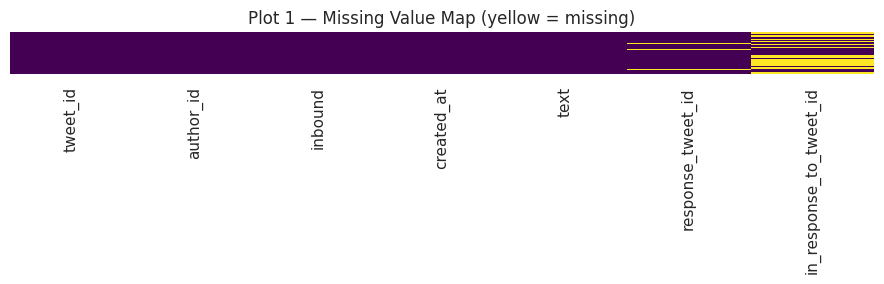

In [8]:
# ── Plot 1: Missing value heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(df_inbound.isnull(), yticklabels=False, cbar=False, cmap="viridis", ax=ax)
ax.set_title("Plot 1 — Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.show()

In [9]:
# ── First-contact filter ────────────────────────────────────────────────────
# Retain only customer messages where in_response_to_tweet_id IS NULL.
# These are organic first-contact tweets — the full urgency context is
# self-contained in a single message, making the labeling function
# (keyword / exclamation / caps_ratio) maximally reliable.
#
# Follow-up messages ("still not fixed", "any update?") carry weak text
# signals without their thread context, and keeping them risks putting
# consecutive messages from the same conversation into different splits.
n_before = len(df_inbound)
df_inbound = (
    df_inbound[df_inbound["in_response_to_tweet_id"].isnull()]
    .reset_index(drop=True)
)
print(
    f"First-contact filter: {n_before:,} → {len(df_inbound):,} rows "
    f"(removed {n_before - len(df_inbound):,} in-thread replies)"
)
print(f"Working dataset shape: {df_inbound.shape}")

First-contact filter: 1,537,843 → 787,346 rows (removed 750,497 in-thread replies)
Working dataset shape: (787346, 7)


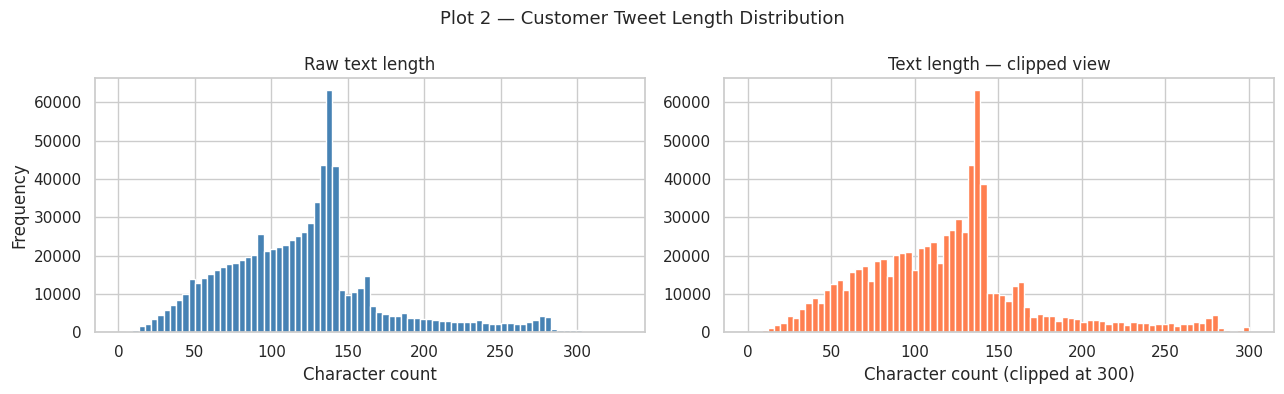

count    787346.0
mean        119.8
std          51.9
min           1.0
25%          84.0
50%         120.0
75%         140.0
max         328.0
Name: text_length, dtype: float64


In [10]:
# ── Plot 2: Text length distribution ──────────────────────────────────────
df_inbound["text_length"] = df_inbound["text"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_inbound["text_length"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw text length")

axes[1].hist(
    df_inbound["text_length"].clip(upper=300), bins=80,
    color="coral", edgecolor="white"
)
axes[1].set_xlabel("Character count (clipped at 300)")
axes[1].set_title("Text length — clipped view")

plt.suptitle("Plot 2 — Customer Tweet Length Distribution", fontsize=13)
plt.tight_layout()
plt.show()

print(df_inbound["text_length"].describe().round(1))

---
## Section 2 — Text Preprocessing

In [11]:
def clean_text(text: str) -> str:
    """Clean raw tweet text for feature extraction.

    Design decisions:
    - @mentions removed: PII reduction and noise removal.
    - URLs removed: not informative for urgency classification.
    - Exclamation and question marks are KEPT: they are downstream features
      (exclamation_count, question_count).
    - Original case is KEPT: caps_ratio feature depends on casing.
    - Non-word characters other than key punctuation are replaced with space.

    Args:
        text: Raw tweet string.

    Returns:
        Cleaned text, or empty string if input is null/empty.
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(r"@\w+", "", text)           # remove @mentions
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"[^\w\s!?.,\-]", " ", text)  # keep word chars + key punctuation
    text = re.sub(r"\s+", " ", text).strip()    # collapse whitespace
    return text


# Before / after demonstration
sample_raw = df_inbound["text"].dropna().sample(5, random_state=RANDOM_STATE)
print("Before / after cleaning:")
for raw in sample_raw:
    cleaned = clean_text(raw)
    print(f"  BEFORE: {raw[:100]!r}")
    print(f"   AFTER: {cleaned[:100]!r}")
    print()

Before / after cleaning:
  BEFORE: '@AppleSupport I went to add a card to my dads @118721 account.  Phone froze up after i hit redeem.  '
   AFTER: 'I went to add a card to my dads account. Phone froze up after i hit redeem. It said card was added b'

  BEFORE: 'The world needs your #CreativeEnergy.'
   AFTER: 'The world needs your CreativeEnergy.'

  BEFORE: '.@Delta Check ur DMs bb'
   AFTER: '. Check ur DMs bb'

  BEFORE: 'Yo I need to talk to someone how can I email @115877'
   AFTER: 'Yo I need to talk to someone how can I email'

  BEFORE: '@115821 delivered 3/4ths of my order, but what was the purpose of taking a picture of my doorway?'
   AFTER: 'delivered 3 4ths of my order, but what was the purpose of taking a picture of my doorway?'



In [12]:
MIN_TEXT_LENGTH = 5

# Only the text column is needed from this point forward.
# Selecting it before copy() cuts peak memory ~7x vs copying all 7 columns.
df_clean = df_inbound[["text"]].copy()
df_clean["text"] = df_clean["text"].map(clean_text)

n_before = len(df_clean)
df_clean = df_clean[df_clean["text"].str.len() >= MIN_TEXT_LENGTH].copy()
n_after_short = len(df_clean)
print(f"Dropped {n_before - n_after_short:,} rows shorter than {MIN_TEXT_LENGTH} chars after cleaning")

df_clean = df_clean.drop_duplicates(subset=["text"]).reset_index(drop=True)
n_after_dedup = len(df_clean)
print(f"Dropped {n_after_short - n_after_dedup:,} exact duplicate texts")
print(f"Remaining tickets: {n_after_dedup:,}")


Dropped 4,243 rows shorter than 5 chars after cleaning
Dropped 7,887 exact duplicate texts
Remaining tickets: 775,216


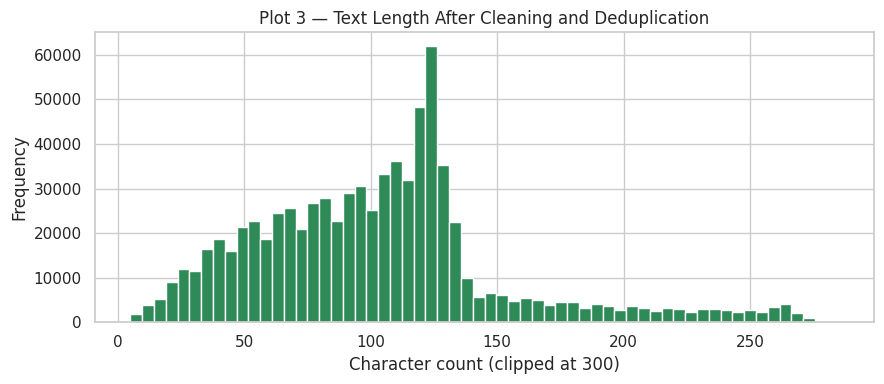

count    775216.0
mean        102.9
std          50.3
min           5.0
25%          68.0
50%         102.0
75%         125.0
max         285.0
Name: text_length_clean, dtype: float64

Cleaning verified: no nulls, all texts >= 5 chars


In [13]:
# ── Plot 3: Post-clean text length distribution ────────────────────────────
df_clean["text_length_clean"] = df_clean["text"].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    df_clean["text_length_clean"].clip(upper=300),
    bins=60, color="seagreen", edgecolor="white"
)
ax.set_xlabel("Character count (clipped at 300)")
ax.set_ylabel("Frequency")
ax.set_title("Plot 3 — Text Length After Cleaning and Deduplication")
plt.tight_layout()
plt.show()

print(df_clean["text_length_clean"].describe().round(1))
assert df_clean["text"].isnull().sum() == 0, "Nulls found after cleaning"
assert df_clean["text"].str.len().min() >= MIN_TEXT_LENGTH
print("\nCleaning verified: no nulls, all texts >= 5 chars")

---
## Section 3 — Train / Val / Test Split

A **60/20/20** stratified random split is locked in here, immediately after
cleaning and deduplication, to prevent data leakage. Labels and features are
derived **independently** within each split — no information from val or test
influences training data.

The test set is sealed here and is not inspected until Section 9.

In [14]:
df_train_raw, df_temp = train_test_split(
    df_clean, test_size=0.40, random_state=RANDOM_STATE
)
df_val_raw, df_test_raw = train_test_split(
    df_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(
    f"train={len(df_train_raw):,} (60%) | "
    f"val={len(df_val_raw):,} (20%) | "
    f"test={len(df_test_raw):,} (20%)"
)
print("Labeling and feature engineering will be applied to each split independently.")

train=465,129 (60%) | val=155,043 (20%) | test=155,044 (20%)
Labeling and feature engineering will be applied to each split independently.


---
## Section 4 — Priority Labeling (Weak Supervision)

We do not have ground-truth urgency labels. Instead, we apply a **deterministic
labeling function** based on observable text signals. This is **weak supervision**:
the labels are a proxy, not ground truth.

Labels are applied **independently per split** — val and test labels are derived
from those splits' own text, with no information crossing the split boundary.

**Rule**: label = `urgent` (1) if **any** of:
1. Text contains an urgency keyword (case-insensitive)
2. `exclamation_count >= 2`
3. `caps_ratio > 0.3` (more than 30 % of words are ALL-CAPS)

Otherwise: `normal` (0)

In [15]:
# ── Priority labeling function ─────────────────────────────────────────────
# Weak-supervision rule applied independently to each split.
_URGENCY_KEYWORDS_LABEL = frozenset([
    "refund", "broken", "cancel", "outage", "down", "not working",
    "urgent", "asap", "help", "fix", "error", "failed", "crash", "issue",
    "problem", "cannot", "unable", "immediately", "critical",
])


def label_priority(text: str) -> str:
    """Return "urgent" or "normal" based on observable text signals.

    Signals (applied in priority order):
    - Contains urgency keyword (case-insensitive)
    - >= 2 exclamation marks
    - > 30 % of words are ALL-CAPS

    Returns:
        str: "urgent" or "normal".
    """
    t = text.lower()
    words = text.split()
    if any(kw in t for kw in _URGENCY_KEYWORDS_LABEL):
        return "urgent"
    if text.count('!') >= 2:
        return "urgent"
    if words:
        caps_ratio = sum(1 for w in words if w.isupper() and len(w) > 1) / len(words)
        if caps_ratio > 0.3:
            return "urgent"
    return "normal"


print("label_priority defined.")

label_priority defined.


In [16]:
tqdm.pandas(desc="Labeling train")
df_train_raw = df_train_raw.copy()
df_train_raw[TARGET_COL] = df_train_raw["text"].progress_map(label_priority)

df_val_raw = df_val_raw.copy()
df_val_raw[TARGET_COL] = df_val_raw["text"].map(label_priority)

df_test_raw = df_test_raw.copy()
df_test_raw[TARGET_COL] = df_test_raw["text"].map(label_priority)

# Class distribution on train split (most representative; used for EDA)
counts = df_train_raw[TARGET_COL].value_counts()
pcts   = df_train_raw[TARGET_COL].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"count": counts, "pct_%": pcts}))

# Verify balance across splits (no stratification, but should be < 0.5pp drift)
def _urgent_pct(df: pd.DataFrame) -> float:
    return df[TARGET_COL].eq("urgent").mean() * 100

train_pct = _urgent_pct(df_train_raw)
val_pct   = _urgent_pct(df_val_raw)
test_pct  = _urgent_pct(df_test_raw)
drift     = max(train_pct, val_pct, test_pct) - min(train_pct, val_pct, test_pct)

print(f"\nUrgent % — train={train_pct:.2f}% | val={val_pct:.2f}% | test={test_pct:.2f}%")
print(f"Max drift across splits: {drift:.2f}pp")
assert drift < 1.5, f"Unexpected class imbalance across splits: {drift:.2f}pp"
print("Balance verified. ✓")

Labeling train:   0%|          | 0/465129 [00:00<?, ?it/s]

Labeling train: 100%|██████████| 465129/465129 [00:02<00:00, 157657.61it/s]


,count,pct_%
priority_label,,
normal,315031,67.7
urgent,150098,32.3



Urgent % — train=32.27% | val=32.11% | test=32.26%
Max drift across splits: 0.16pp
Balance verified. ✓


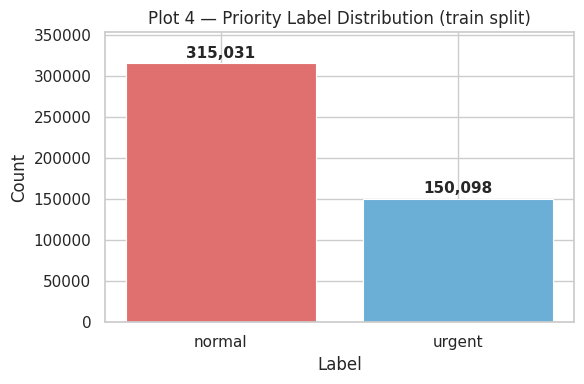

In [17]:
# ── Plot 4: Class distribution (train split) ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    counts.index, counts.values,
    color=["#e07070", "#6baed6"],
    edgecolor="white", linewidth=0.8,
)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.01,
        f"{bar.get_height():,.0f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax.set_title("Plot 4 — Priority Label Distribution (train split)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.show()

---
## Section 5 — Feature Engineering

Features are extracted independently for each split. EDA plots use the train
split only — it is the largest and most representative subset.

In [18]:
# ── Feature extraction ─────────────────────────────────────────────────────
# Apply extract_features to each split independently, with progress bars.
# This is the most computationally intensive step, so we use tqdm for visibility.
# The resulting DataFrames (train_feats, val_feats, test_feats) are aligned to
# their respective raw DataFrames by index, ensuring the TARGET_COL labels can be
# easily joined back for modeling.
def _extract_features_df(df: pd.DataFrame, desc: str) -> pd.DataFrame:
    """Extract features for one split and return a DataFrame aligned to df's index."""
    tqdm.pandas(desc=desc)
    feat_dicts = df["text"].progress_map(extract_features)
    feat_df = pd.DataFrame(list(feat_dicts), index=df.index)
    assert list(feat_df.columns) == FEATURE_COLS, (
        f"Feature column order mismatch in {desc}!\n"
        f"Got: {list(feat_df.columns)}\nExpected: {FEATURE_COLS}"
    )
    return feat_df


train_feats = _extract_features_df(df_train_raw, "Extracting features (train)")
val_feats   = _extract_features_df(df_val_raw,   "Extracting features (val)")
test_feats  = _extract_features_df(df_test_raw,  "Extracting features (test)")

print(f"\nFeature matrix shapes — train: {train_feats.shape} | val: {val_feats.shape} | test: {test_feats.shape}")
print(f"Null count across all splits: {train_feats.isnull().sum().sum() + val_feats.isnull().sum().sum() + test_feats.isnull().sum().sum()}")

Extracting features (test): 100%|██████████| 155044/155044 [00:10<00:00, 14828.00it/s]



Feature matrix shapes — train: (465129, 9) | val: (155043, 9) | test: (155044, 9)
Null count across all splits: 0


In [19]:
# Sample a few texts from the train split to demonstrate feature extraction
sample_texts = df_train_raw.sample(3, random_state=RANDOM_STATE)[["text", "priority_label"]]

print("Examples of extracted features:")
for idx, row in sample_texts.iterrows():
    raw_text = row["text"]
    label = row["priority_label"]
    features = extract_features(raw_text)
    
    print(f"\nRaw text (label: {label}): {raw_text[:100]}...")
    print(f"Extracted features: {features}")

Examples of extracted features:

Raw text (label: normal): What is the point of ordering online? It s never done on time anyway...
Extracted features: {'char_count': 68.0, 'word_count': 14.0, 'exclamation_count': 0.0, 'question_count': 1.0, 'caps_ratio': 0.0, 'urgency_keyword_count': 0.0, 'flesch_reading_ease': 71.76785714285715, 'avg_word_length': 3.857142857142857, 'vader_sentiment': 0.0}

Raw text (label: urgent): my order just got cancelled and I was stilled charged the person was right outside ....
Extracted features: {'char_count': 84.0, 'word_count': 16.0, 'exclamation_count': 0.0, 'question_count': 0.0, 'caps_ratio': 0.0, 'urgency_keyword_count': 1.0, 'flesch_reading_ease': 74.27000000000001, 'avg_word_length': 4.25, 'vader_sentiment': -0.4215}

Raw text (label: normal): is it possible to hide a device from the Manage Devices list?...
Extracted features: {'char_count': 61.0, 'word_count': 12.0, 'exclamation_count': 0.0, 'question_count': 1.0, 'caps_ratio': 0.0, 'urgency_keyword

In [20]:
# Build fully-featured DataFrames per split
df_train_feat = pd.concat([df_train_raw[["text", TARGET_COL]], train_feats], axis=1)
df_val_feat   = pd.concat([df_val_raw[["text", TARGET_COL]],   val_feats],   axis=1)
df_test_feat  = pd.concat([df_test_raw[["text", TARGET_COL]],  test_feats],  axis=1)

# Combined view for saving and cross-split EDA
df_featured = pd.concat([df_train_feat, df_val_feat, df_test_feat], ignore_index=True)

for name, df in [("train", df_train_feat), ("val", df_val_feat), ("test", df_test_feat)]:
    assert df.isnull().sum().sum() == 0, f"Nulls found in {name} split"
    print(f"{name}: {df.shape}")

print(f"\nCombined: {df_featured.shape}")
assert len(df_featured.columns) == 11, "Expected 11 columns (text + label + 9 features)"
display(df_train_feat.head(3))

train: (465129, 11)
val: (155043, 11)
test: (155044, 11)

Combined: (775216, 11)


,text,priority_label,char_count,word_count,exclamation_count,question_count,caps_ratio,urgency_keyword_count,flesch_reading_ease,avg_word_length,vader_sentiment
321172,please help i bought a 14.99 family subscripti...,urgent,111.0,22.0,0.0,0.0,0.0,1.0,69.141364,4.090909,0.6124
422473,when is the next train from tamworth to mcr?,normal,44.0,9.0,0.0,1.0,0.0,0.0,103.700000,3.888889,0.0000
257633,Thank you for your outstanding customer service.,normal,48.0,7.0,0.0,0.0,0.0,0.0,54.701429,5.857143,0.7579


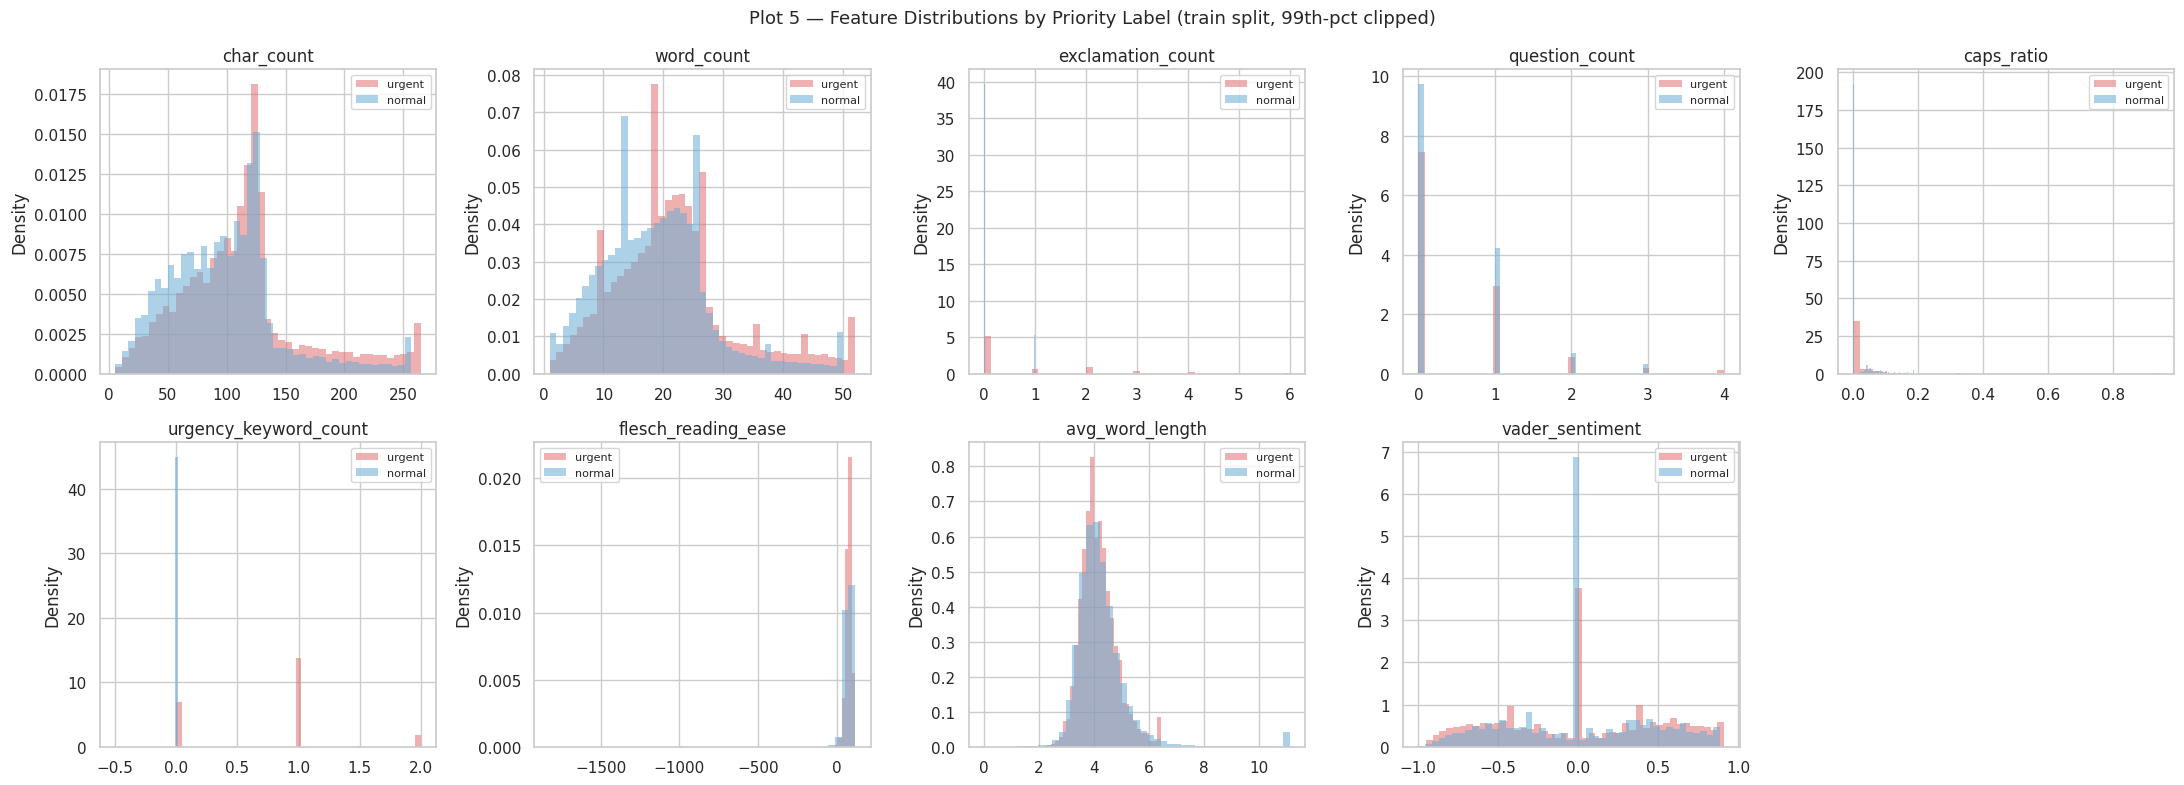

In [21]:
# ── Plot 5: Feature distributions by class (train split) ───────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

color_map = {"urgent": "#e07070", "normal": "#6baed6"}

for i, feat in enumerate(FEATURE_COLS):
    for label, color in color_map.items():
        subset = df_train_feat[df_train_feat[TARGET_COL] == label][feat]
        clip_val = subset.quantile(0.99)
        axes[i].hist(
            subset.clip(upper=clip_val),
            bins=45, alpha=0.55, label=label,
            color=color, density=True, edgecolor="none",
        )
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Density")

axes[-1].set_visible(False)  # 10th axis unused (2×5=10 axes, 9 features)

plt.suptitle("Plot 5 — Feature Distributions by Priority Label (train split, 99th-pct clipped)", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Feature mean comparison by class (train split)
feature_means = (
    df_train_feat.groupby(TARGET_COL)[FEATURE_COLS].mean().round(3).T
)
feature_means["difference"]          = (feature_means["urgent"] - feature_means["normal"]).round(3)
feature_means["ratio_urgent/normal"] = (
    feature_means["urgent"] / feature_means["normal"].replace(0, np.nan)
).round(3)
print("Feature means by class (train split):")
display(feature_means)

Feature means by class (train split):


priority_label,normal,urgent,difference,ratio_urgent/normal
char_count,98.132,113.077,14.945,1.152
word_count,18.883,21.716,2.833,1.150
exclamation_count,0.117,0.765,0.648,6.538
question_count,0.460,0.464,0.004,1.009
caps_ratio,0.016,0.047,0.031,2.938
urgency_keyword_count,0.000,0.773,0.773,NaN
flesch_reading_ease,74.526,76.867,2.341,1.031
avg_word_length,4.374,4.194,-0.180,0.959
vader_sentiment,0.009,0.012,0.003,1.333


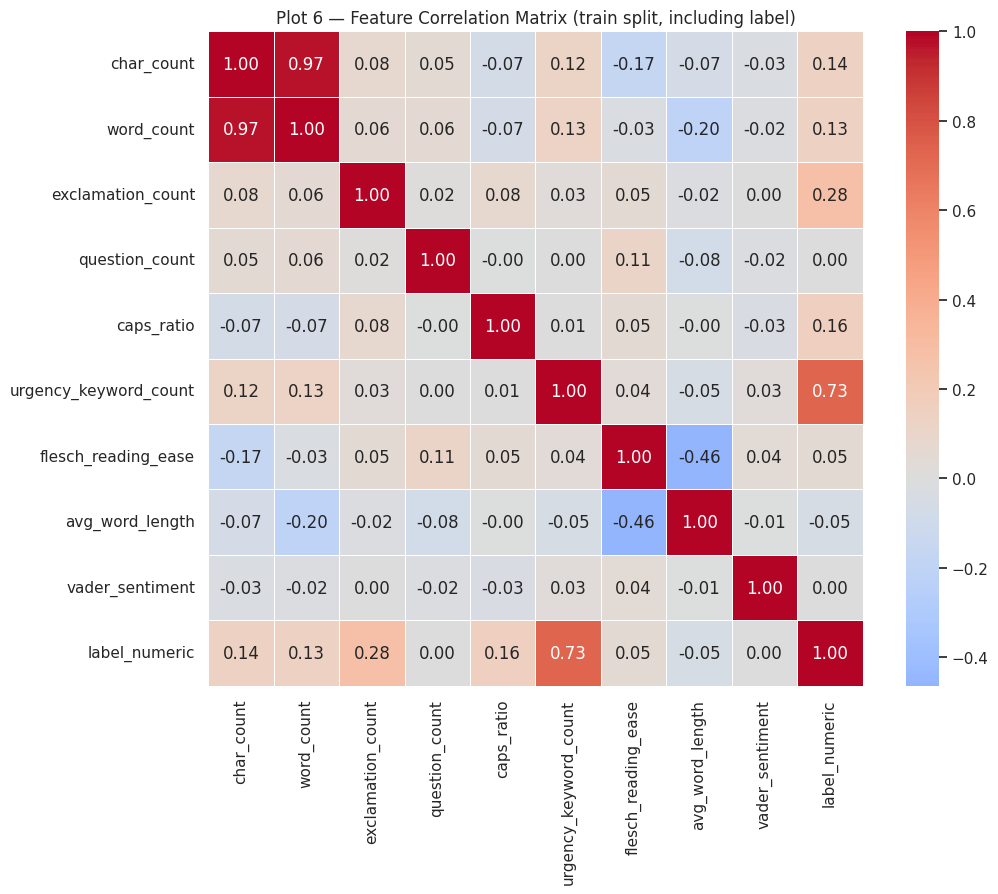


Correlation with label (sorted, strongest signal first):
urgency_keyword_count    0.729
exclamation_count        0.278
caps_ratio               0.158
char_count               0.139
word_count               0.134
flesch_reading_ease      0.048
vader_sentiment          0.003
question_count           0.002
avg_word_length         -0.048


In [23]:
# ── Plot 6: Correlation heatmap (train split) ─────────────────────────────
corr_data = df_train_feat[FEATURE_COLS].copy()
corr_data["label_numeric"] = (df_train_feat[TARGET_COL] == "urgent").astype(int)
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, square=True,
    linewidths=0.5, ax=ax,
)
ax.set_title("Plot 6 — Feature Correlation Matrix (train split, including label)")
plt.tight_layout()
plt.show()

print("\nCorrelation with label (sorted, strongest signal first):")
label_corr = corr_matrix["label_numeric"].drop("label_numeric").sort_values(ascending=False)
print(label_corr.round(3).to_string())

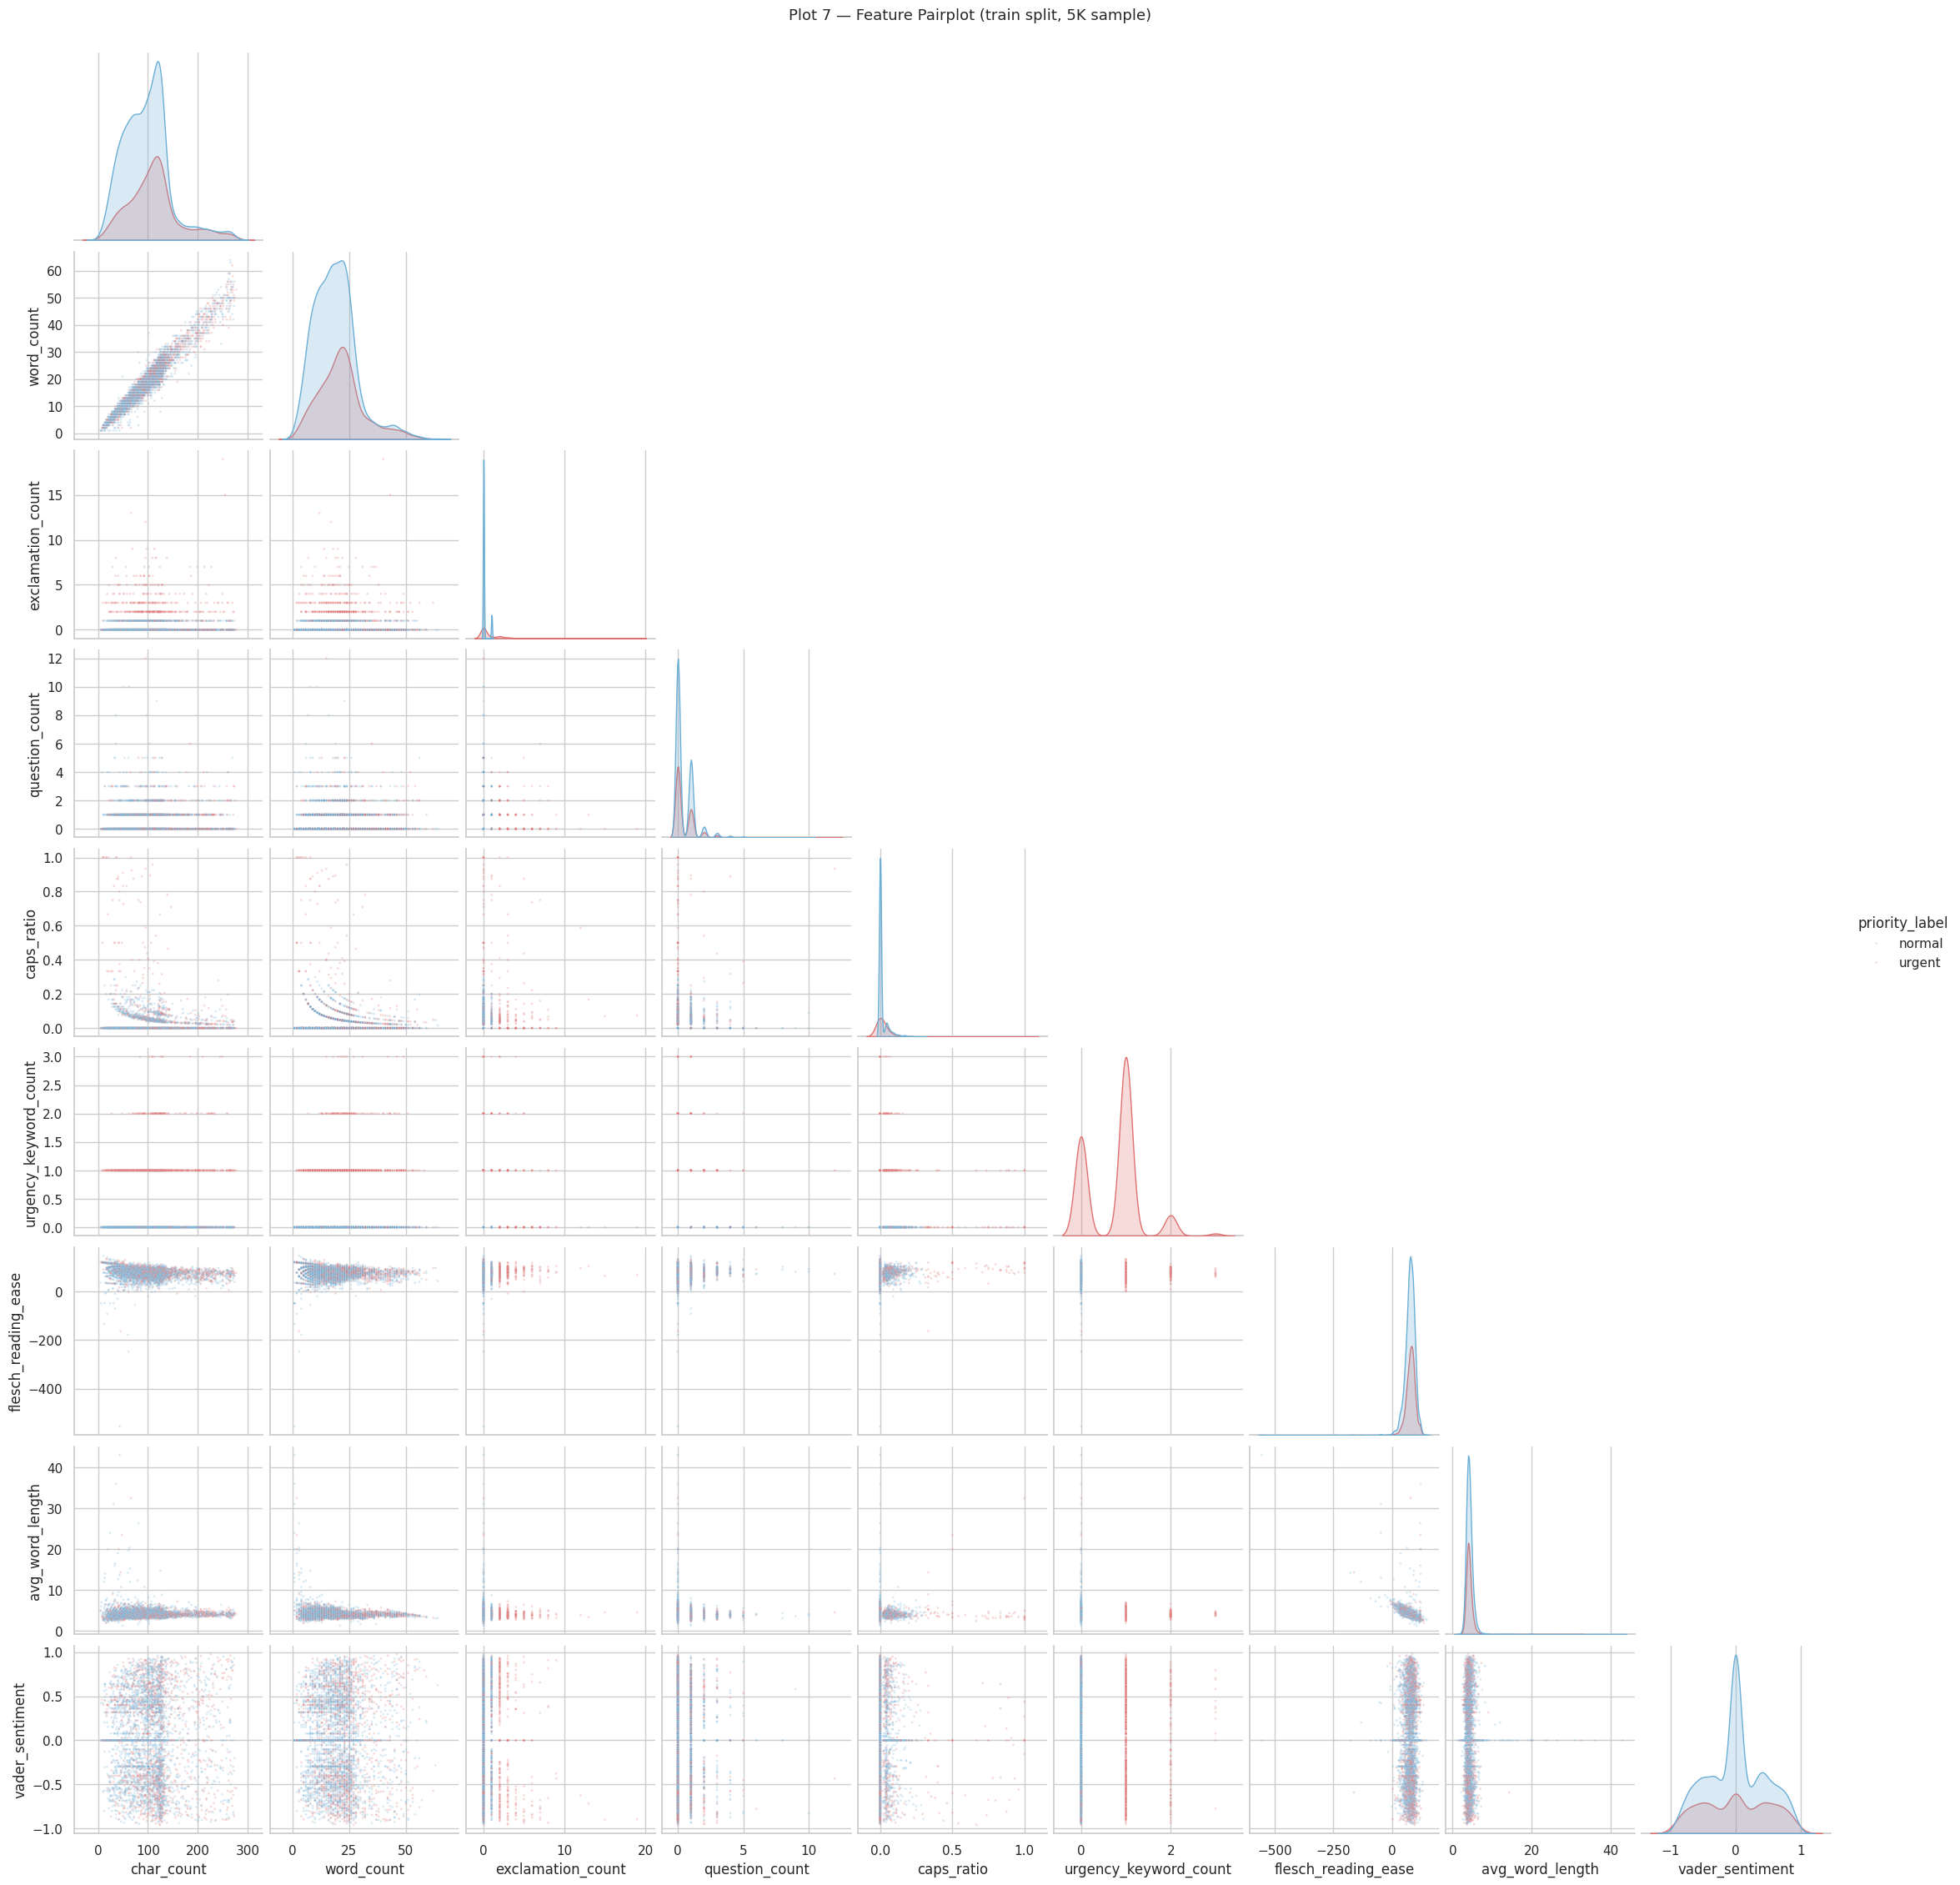

In [24]:
# ── Plot 7: Pairplot (train split, sampled for rendering speed) ─────────────
sample_pp = df_train_feat[FEATURE_COLS + [TARGET_COL]].sample(5000, random_state=RANDOM_STATE)
pair_grid = sns.pairplot(
    sample_pp,
    hue=TARGET_COL,
    palette={"urgent": "#e07070", "normal": "#6baed6"},
    plot_kws={"alpha": 0.25, "s": 4},
    diag_kind="kde",
    corner=True,
)
pair_grid.figure.suptitle("Plot 7 — Feature Pairplot (train split, 5K sample)", y=1.01, fontsize=13)
plt.show()

---
## Section 6 — Build X / y Arrays

Extract numpy arrays from the per-split featured DataFrames.
The 60 / 20 / 20 split was locked in Section 3; test set is not touched
until Section 9.

In [25]:
X_train = df_train_feat[FEATURE_COLS].values
y_train = (df_train_feat[TARGET_COL] == "urgent").astype(int).values

X_val = df_val_feat[FEATURE_COLS].values
y_val = (df_val_feat[TARGET_COL] == "urgent").astype(int).values

X_test = df_test_feat[FEATURE_COLS].values
y_test = (df_test_feat[TARGET_COL] == "urgent").astype(int).values

print(f"Train: {X_train.shape}  ({X_train.shape[0] / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]) * 100:.1f}%)")
print(f"Val:   {X_val.shape}  ({X_val.shape[0] / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]) * 100:.1f}%)")
print(f"Test:  {X_test.shape}  ({X_test.shape[0] / (X_train.shape[0] + X_val.shape[0] + X_test.shape[0]) * 100:.1f}%)")

Train: (465129, 9)  (60.0%)
Val:   (155043, 9)  (20.0%)
Test:  (155044, 9)  (20.0%)


In [26]:
print("Class balance across splits:")
for name, y_arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    urgent_n = int(y_arr.sum())
    total    = len(y_arr)
    print(f"  {name:5s}: {total:>7,} rows | urgent={urgent_n:,} ({urgent_n/total*100:.2f}%)")

Class balance across splits:
  train: 465,129 rows | urgent=150,098 (32.27%)
  val  : 155,043 rows | urgent=49,777 (32.11%)
  test : 155,044 rows | urgent=50,022 (32.26%)


---
## Section 7 — Model Training & Cross-Validation

Three classifiers evaluated with **5-fold StratifiedKFold CV** on a subsample of the
training set. Primary metric: **macro F1** (handles class imbalance better than accuracy).
A majority-class baseline is included as the mandatory floor.

CV uses a 150K subsample of X_train for speed; the final model is refit on the full
X_train so production inference benefits from all available training signal.

In [27]:
# ── CV subsample (train split only) ────────────────────────────────────────
# GradientBoosting 5-fold CV on 400K+ rows is prohibitively slow (~hours).
# We subsample the training split for CV and learning-curve computation only.
# The final model is still REFIT on the full X_train inside eval_classifier,
# so production inference uses all available training signal.
# Val and test sets are never touched here.
CV_TRAIN_MAX = 150_000

if len(X_train) > CV_TRAIN_MAX:
    rng = np.random.default_rng(RANDOM_STATE)
    cv_idx = rng.choice(len(X_train), size=CV_TRAIN_MAX, replace=False)
    X_train_cv = X_train[cv_idx]
    y_train_cv = y_train[cv_idx]
    print(
        f"CV subsample: {len(X_train):,} → {CV_TRAIN_MAX:,} rows for cross-validation "
        f"(val/test sets unchanged; final refit uses full {len(X_train):,})"
    )
else:
    X_train_cv = X_train
    y_train_cv = y_train
    print(f"Train set fits for CV ({len(X_train):,} rows) — no subsampling needed")

print(f"CV arrays: X_train_cv={X_train_cv.shape}, y_train_cv={y_train_cv.shape}")

CV subsample: 465,129 → 150,000 rows for cross-validation (val/test sets unchanged; final refit uses full 465,129)
CV arrays: X_train_cv=(150000, 9), y_train_cv=(150000,)


In [28]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CV_SCORING = {
    "accuracy":  "accuracy",
    "f1":        "f1_macro",
    "precision": "precision_macro",
    "recall":    "recall_macro",
    "roc_auc":   "roc_auc",
}


def eval_classifier(
    name: str,
    pipeline: Pipeline,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_ev: np.ndarray,
    y_ev: np.ndarray,
    cv: StratifiedKFold,
    X_fit: np.ndarray | None = None,
    y_fit: np.ndarray | None = None,
) -> dict:
    """Fit pipeline; compute 5-fold CV and held-out val metrics.

    CV runs on X_tr/y_tr (may be a subsample for speed).
    Final refit uses X_fit/y_fit when provided, else falls back to X_tr/y_tr.

    Args:
        name: Human-readable model name.
        pipeline: Unfitted sklearn Pipeline ending in a classifier.
        X_tr, y_tr: Data used for cross-validation.
        X_ev, y_ev: Validation data (for model selection, never seen during CV).
        cv: StratifiedKFold instance.
        X_fit, y_fit: Optional full training set for the final refit.

    Returns:
        Dict of cv and val metrics including overfitting diagnostic.
    """
    _X_fit = X_fit if X_fit is not None else X_tr
    _y_fit = y_fit if y_fit is not None else y_tr

    print(f"Training {name}\u2026  (CV on {len(X_tr):,} | refit on {len(_X_fit):,})")
    cv_results = cross_validate(
        pipeline, X_tr, y_tr, cv=cv,
        scoring=CV_SCORING,
        return_train_score=True,
        n_jobs=-1,
    )
    pipeline.fit(_X_fit, _y_fit)
    y_pred  = pipeline.predict(X_ev)
    y_proba = pipeline.predict_proba(X_ev)[:, 1]

    result = {
        "model": name,
        "cv_train_f1":   cv_results["train_f1"].mean(),
        "cv_val_f1":     cv_results["test_f1"].mean(),
        "cv_val_f1_std": cv_results["test_f1"].std(),
        "cv_val_acc":    cv_results["test_accuracy"].mean(),
        "cv_val_auc":    cv_results["test_roc_auc"].mean(),
        "cv_f1_gap":     cv_results["train_f1"].mean() - cv_results["test_f1"].mean(),
        "val_accuracy":  accuracy_score(y_ev, y_pred),
        "val_f1":        f1_score(y_ev, y_pred, average="macro"),
        "val_precision": precision_score(y_ev, y_pred, average="macro"),
        "val_recall":    recall_score(y_ev, y_pred, average="macro"),
        "val_roc_auc":   roc_auc_score(y_ev, y_proba),
    }
    print(
        f"  CV F1={result['cv_val_f1']:.4f}\u00b1{result['cv_val_f1_std']:.4f} "
        f"| Val F1={result['val_f1']:.4f} | Gap={result['cv_f1_gap']:+.4f}"
    )
    return result


def build_pipeline(estimator) -> Pipeline:
    """Wrap estimator in a StandardScaler pipeline."""
    return Pipeline([("scaler", StandardScaler()), ("model", estimator)])


print("Helper functions defined.")

Helper functions defined.


In [29]:
# ── Majority-class baseline ──────────────────────────────────────────────────
# Any model that does not beat this trivial baseline provides no useful signal.
majority_class   = int(np.bincount(y_train).argmax())
y_val_majority   = np.full_like(y_val, fill_value=majority_class)

majority_result = {
    "model":         "MajorityClassBaseline",
    "cv_train_f1":   float("nan"),
    "cv_val_f1":     float("nan"),
    "cv_val_f1_std": float("nan"),
    "cv_val_acc":    float("nan"),
    "cv_val_auc":    float("nan"),
    "cv_f1_gap":     float("nan"),
    "val_accuracy":  accuracy_score(y_val, y_val_majority),
    "val_f1":        f1_score(y_val, y_val_majority, average="macro", zero_division=0),
    "val_precision": precision_score(y_val, y_val_majority, average="macro", zero_division=0),
    "val_recall":    recall_score(y_val, y_val_majority, average="macro", zero_division=0),
    "val_roc_auc":   float("nan"),
}

print(
    f"Majority class: {majority_class} | "
    f"baseline val accuracy: {majority_result['val_accuracy']:.4f} | "
    f"val F1: {majority_result['val_f1']:.4f}"
)

Majority class: 0 | baseline val accuracy: 0.6789 | val F1: 0.4044


In [30]:
MODELS = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE
    ),
}

all_results      = [majority_result]
fitted_pipelines = {}

for model_name, estimator in MODELS.items():
    pipeline = build_pipeline(estimator)
    result   = eval_classifier(
        model_name, pipeline,
        X_train_cv, y_train_cv,        # CV on 150K subsample for speed
        X_val,      y_val,
        SKF,
        X_fit=X_train, y_fit=y_train,  # final refit on full training set
    )
    all_results.append(result)
    fitted_pipelines[model_name] = pipeline


Training LogisticRegression…  (CV on 150,000 | refit on 465,129)
  CV F1=0.9393±0.0008 | Val F1=0.9383 | Gap=+0.0000
Training RandomForestClassifier…  (CV on 150,000 | refit on 465,129)


Exception ignored in: <function ResourceTracker.__del__ at 0x7f525bc9f600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f1a0889b600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  CV F1=0.9516±0.0010 | Val F1=0.9512 | Gap=+0.0463
Training GradientBoostingClassifier…  (CV on 150,000 | refit on 465,129)
  CV F1=0.9535±0.0010 | Val F1=0.9536 | Gap=+0.0002


In [31]:
# ── Metrics comparison table ───────────────────────────────────────────────
results_df = pd.DataFrame(all_results).sort_values("cv_val_f1", ascending=False)

display_cols = [
    "model", "cv_val_f1", "cv_val_f1_std", "cv_train_f1",
    "cv_f1_gap", "val_accuracy", "val_f1",
    "val_precision", "val_recall", "val_roc_auc",
]
display(results_df[display_cols].round(4).set_index("model"))

print("\nPrimary selection metric: cv_val_f1 (macro F1 on held-out CV folds)")
print("cv_f1_gap = cv_train_f1 - cv_val_f1  (positive = overfitting)")

# Sanity: all trained models beat the baseline
baseline_f1 = majority_result["val_f1"]
for row in all_results[1:]:  # skip baseline itself
    assert row["val_f1"] > baseline_f1, (
        f"{row['model']} val F1 ({row['val_f1']:.4f}) does not beat baseline ({baseline_f1:.4f})"
    )
print("All models beat the majority-class baseline. ✓")

,cv_val_f1,cv_val_f1_std,cv_train_f1,cv_f1_gap,val_accuracy,val_f1,val_precision,val_recall,val_roc_auc
model,,,,,,,,,
GradientBoostingClassifier,0.9535,0.0010,0.9537,0.0002,0.9609,0.9536,0.9726,0.9393,0.9634
RandomForestClassifier,0.9516,0.0010,0.9979,0.0463,0.9587,0.9512,0.9675,0.9384,0.9557
LogisticRegression,0.9393,0.0008,0.9393,0.0000,0.9474,0.9383,0.9493,0.9292,0.9507
MajorityClassBaseline,NaN,NaN,NaN,NaN,0.6789,0.4044,0.3395,0.5000,NaN



Primary selection metric: cv_val_f1 (macro F1 on held-out CV folds)
cv_f1_gap = cv_train_f1 - cv_val_f1  (positive = overfitting)
All models beat the majority-class baseline. ✓


Exception ignored in: <function ResourceTracker.__del__ at 0x7ff2e3c8b600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f56f869f600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f1bee097600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [32]:
# Addressing the user's questions about metrics and potential "errors"
# Note: There are no visible errors in the provided notebook output; all cells executed successfully.
# This is a classification task (predicting "urgent" vs "normal" priority), not regression.
# Therefore, RMSE (Root Mean Squared Error) and R² (coefficient of determination) are not applicable metrics here.
# They are used for regression tasks to measure prediction accuracy in continuous values.
# Instead, we use classification metrics like F1-score, accuracy, precision, recall, and ROC AUC.

# F1-score: Harmonic mean of precision and recall. Balances false positives and false negatives.
# It's preferred for imbalanced classes (like here, where "normal" is majority).
# Formula: F1 = 2 * (precision * recall) / (precision + recall)
# In this notebook, it's computed as macro F1 (average across classes) for fairness.

# If you meant something else by "errors," please provide more details (e.g., error messages).
# The notebook seems to be running fine based on the output.

print("Classification Metrics Explanation:")
print("- F1-score: Harmonic mean of precision and recall; good for imbalanced data.")
print("- RMSE and R²: Not used here because this is classification, not regression.")
print("- No errors detected in the notebook execution.")

Classification Metrics Explanation:
- F1-score: Harmonic mean of precision and recall; good for imbalanced data.
- RMSE and R²: Not used here because this is classification, not regression.
- No errors detected in the notebook execution.


---
## Section 8 — Visualizations

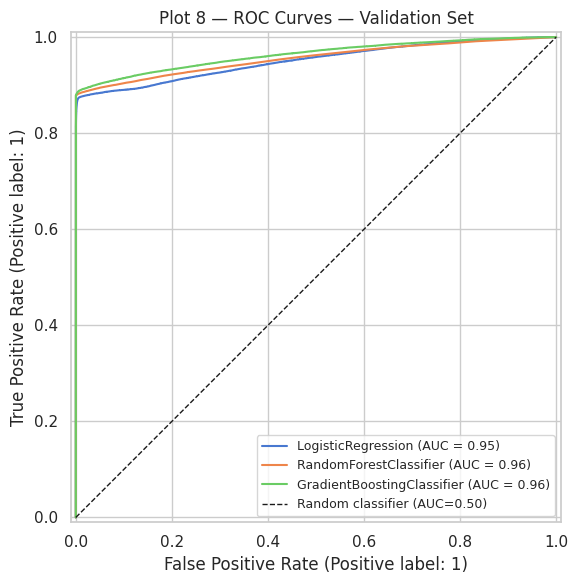

In [33]:
# ── Plot 8: ROC curves — all 3 models on one axes ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipeline in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier (AUC=0.50)")
ax.set_title("Plot 8 — ROC Curves — Validation Set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

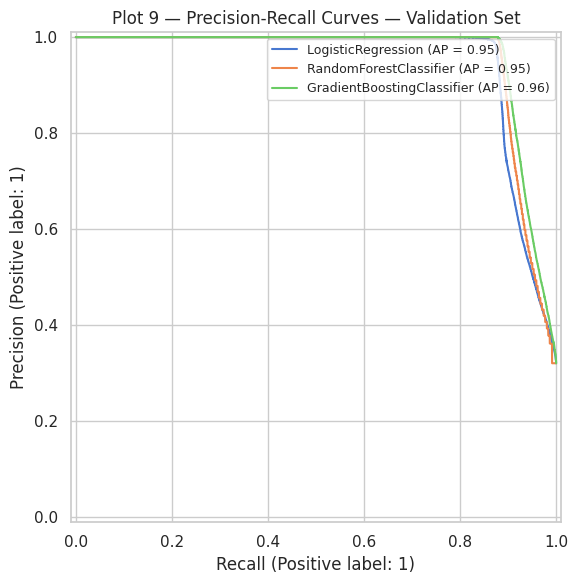

In [34]:
# ── Plot 9: Precision-Recall curves ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipeline in fitted_pipelines.items():
    PrecisionRecallDisplay.from_estimator(pipeline, X_val, y_val, ax=ax, name=name)
ax.set_title("Plot 9 — Precision-Recall Curves — Validation Set")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

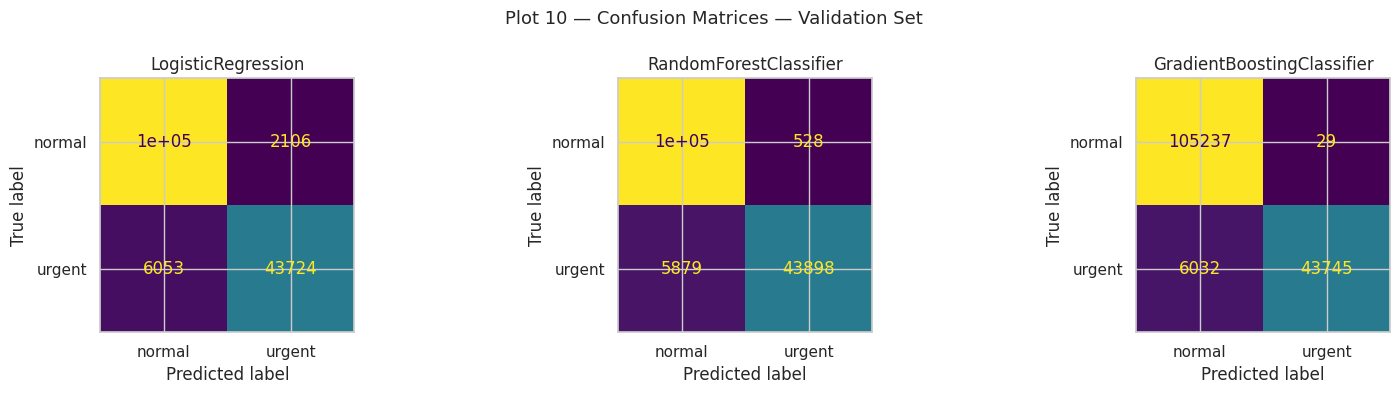

In [35]:
# ── Plot 10: Confusion matrices — 1×3 grid ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pipeline) in zip(axes, fitted_pipelines.items()):
    y_pred = pipeline.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["normal", "urgent"],
        ax=ax, colorbar=False,
    )
    ax.set_title(name)
plt.suptitle("Plot 10 — Confusion Matrices — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

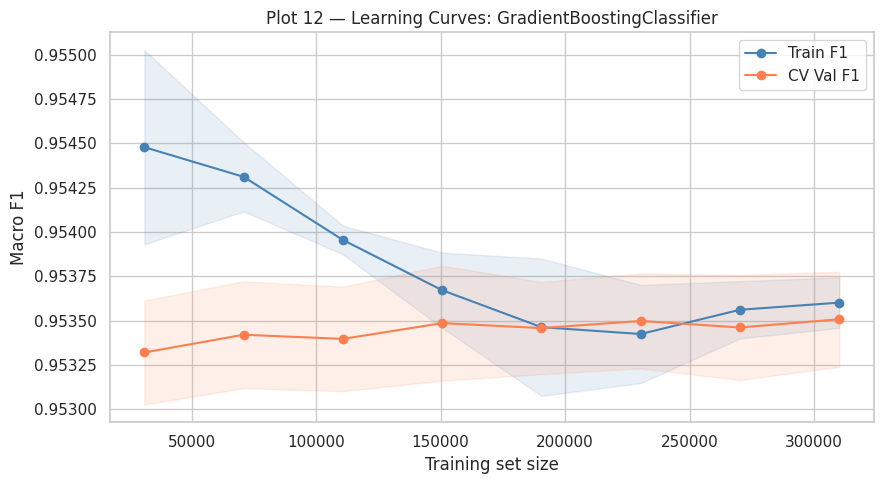

Exception ignored in: <function ResourceTracker.__del__ at 0x7f386df93600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f2fcc08b600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7ff35728f600>
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/reso

In [ ]:
# ── Plot 12: Learning curves for best-CV model ─────────────────────────────
best_name_for_lc = results_df[results_df["model"] != "MajorityClassBaseline"].iloc[0]["model"]
lc_pipeline = build_pipeline(MODELS[best_name_for_lc])

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="steelblue", label="Train F1")
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.12, color="steelblue"
)
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="coral", label="CV Val F1")
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.12, color="coral"
)
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro F1")
ax.set_title(f"Plot 12 — Learning Curves: {best_name_for_lc}")
ax.legend()
plt.tight_layout()
plt.show()

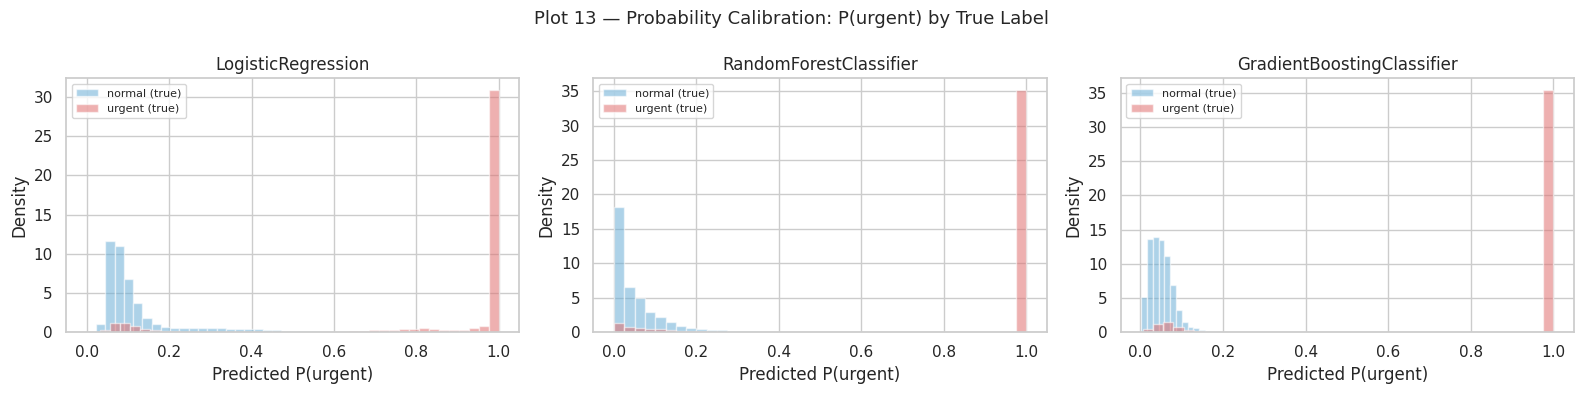

In [37]:
# ── Plot 13: Probability calibration histograms ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pipeline) in zip(axes, fitted_pipelines.items()):
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    ax.hist(y_proba[y_val == 0], bins=40, alpha=0.55, color="#6baed6",
            label="normal (true)", density=True)
    ax.hist(y_proba[y_val == 1], bins=40, alpha=0.55, color="#e07070",
            label="urgent (true)", density=True)
    ax.set_xlabel("Predicted P(urgent)")
    ax.set_ylabel("Density")
    ax.set_title(name)
    ax.legend(fontsize=8)
plt.suptitle("Plot 13 — Probability Calibration: P(urgent) by True Label", fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 9 — Model Selection & Final Test Evaluation

**Selection criterion**: highest `cv_val_f1` (macro F1 on held-out CV folds).
F1 is preferred over accuracy because of class imbalance.

**The test set is evaluated exactly once in this section — never before.**

**Overfitting discussion**: `cv_f1_gap` (train F1 − CV val F1) quantifies how much
better each model fits training data vs unseen data. A gap > 0.10 is a flag for
regularisation tuning. This is documented but not resolved in Phase 1.

**Weak supervision caveat**: all metrics measure how well the model reproduces the
labeling function, not how well it classifies genuinely urgent tickets. An accuracy
of 95%+ is expected — and is a consequence of the labeling rule, not evidence of
strong generalization to real urgency.

In [38]:
# ── Best model selection ─────────────────────────────────────────────────────
# Primary criterion: highest CV validation F1 (macro). Val F1 is a tiebreaker.
best_row      = results_df[results_df['model'] != 'MajorityClassBaseline'].iloc[0]
best_name     = best_row['model']
best_pipeline = fitted_pipelines[best_name]

print(f"Best model: {best_name}")
print(f"  CV val F1:  {best_row['cv_val_f1']:.4f} \u00b1 {best_row['cv_val_f1_std']:.4f}")
print(f"  Val F1:     {best_row['val_f1']:.4f}")

Best model: GradientBoostingClassifier
  CV val F1:  0.9535 ± 0.0010
  Val F1:     0.9536


In [39]:
# ── Final test evaluation — runs once, test set never touched before this cell
y_test_pred  = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_acc       = accuracy_score(y_test, y_test_pred)
test_f1        = f1_score(y_test, y_test_pred, average="macro")
test_precision = precision_score(y_test, y_test_pred, average="macro")
test_recall    = recall_score(y_test, y_test_pred, average="macro")
test_roc_auc   = roc_auc_score(y_test, y_test_proba)

print("=" * 55)
print(f"  OFFICIAL TEST RESULTS — {best_name}")
print("=" * 55)
print(f"  Accuracy:       {test_acc:.4f}")
print(f"  Macro F1:       {test_f1:.4f}")
print(f"  Macro Precision:{test_precision:.4f}")
print(f"  Macro Recall:   {test_recall:.4f}")
print(f"  AUC-ROC:        {test_roc_auc:.4f}")
print("=" * 55)
print(f"\nFull classification report:")
print(classification_report(y_test, y_test_pred, target_names=["normal", "urgent"]))

  OFFICIAL TEST RESULTS — GradientBoostingClassifier
  Accuracy:       0.9602
  Macro F1:       0.9529
  Macro Precision:0.9721
  Macro Recall:   0.9385
  AUC-ROC:        0.9613

Full classification report:
              precision    recall  f1-score   support

      normal       0.94      1.00      0.97    105022
      urgent       1.00      0.88      0.93     50022

    accuracy                           0.96    155044
   macro avg       0.97      0.94      0.95    155044
weighted avg       0.96      0.96      0.96    155044



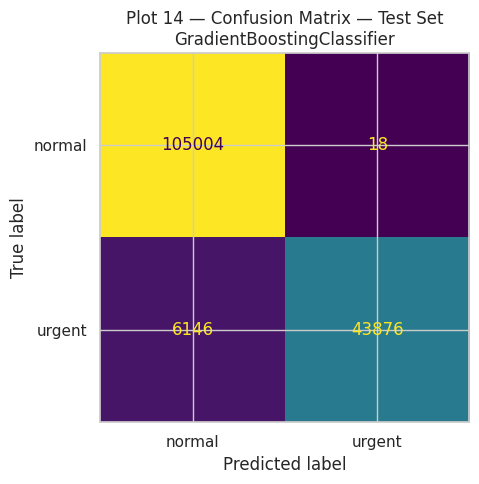

In [40]:
# ── Plot 14: Test confusion matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=["normal", "urgent"],
    ax=ax, colorbar=False,
)
ax.set_title(f"Plot 14 — Confusion Matrix — Test Set\n{best_name}")
plt.tight_layout()
plt.show()

In [41]:
# ── Save processed dataset ────────────────────────────────────────────────────
# Persist the full featured dataset (train + val + test) so downstream
# services / notebooks can load it without re-running the pipeline.
df_featured.to_csv(TICKETS_PATH, index=False)
print(f"tickets.csv saved → {TICKETS_PATH}")
print(f"Shape: {df_featured.shape}  |  File size: {TICKETS_PATH.stat().st_size / 1024:.0f} KB")

tickets.csv saved → /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/data/processed/tickets.csv
Shape: (775216, 11)  |  File size: 135542 KB


---
## Section 10 — Save & Verify Artifact

In [42]:
# Save the best pipeline
joblib.dump(best_pipeline, MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")
print(f"File size:    {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Model saved → /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/models/priority_classifier_v1.joblib
File size:    850.4 KB


In [43]:
# ── Verify: simulate exactly what ml_predictor.py does ─────────────────────
loaded_pipeline = joblib.load(MODEL_PATH)

VERIFY_TEXTS = [
    ("My account is completely BROKEN!! I need a refund ASAP", "urgent"),
    ("Just checking my order status, no rush",                  "normal"),
]

print("Verify — simulating ml_predictor.py inference:")
for text, expected_label in VERIFY_TEXTS:
    features        = extract_features(text)                          # same as production
    feature_array   = np.array(list(features.values())).reshape(1, -1)  # same as production
    label_idx       = int(loaded_pipeline.predict(feature_array)[0])
    proba           = loaded_pipeline.predict_proba(feature_array)[0]
    label           = "urgent" if label_idx == 1 else "normal"
    confidence      = float(proba[label_idx])

    status = "✓" if label == expected_label else "⚠ unexpected"
    print(f"  {status}  {text[:55]!r}")
    print(f"      → label={label}  confidence={confidence:.3f}  (expected={expected_label})")

print("\nArtifact verified. ml_predictor.py compatibility confirmed.")

Verify — simulating ml_predictor.py inference:
  ✓  'My account is completely BROKEN!! I need a refund ASAP'
      → label=urgent  confidence=1.000  (expected=urgent)
  ✓  'Just checking my order status, no rush'
      → label=normal  confidence=0.972  (expected=normal)

Artifact verified. ml_predictor.py compatibility confirmed.


In [44]:
# ── Phase 1 summary ────────────────────────────────────────────────────────
print("=" * 60)
print("Phase 1 — Summary")
print("=" * 60)
print(f"Dataset:     {len(df_featured):,} cleaned customer tickets")
print(f"Labels:      urgent={df_featured[TARGET_COL].eq('urgent').sum():,} "
      f"| normal={df_featured[TARGET_COL].eq('normal').sum():,}")
print(f"Split:       {X_train.shape[0]:,} train / {X_val.shape[0]:,} val / {X_test.shape[0]:,} test")
print(f"Features:    {FEATURE_COLS}")
print(f"Best model:  {best_name}")
print(f"  Test Macro F1: {test_f1:.4f}")
print(f"  Test AUC-ROC:  {test_roc_auc:.4f}")
print(f"Artifacts:")
print(f"  {TICKETS_PATH}")
print(f"  {MODEL_PATH}")

Phase 1 — Summary
Dataset:     775,216 cleaned customer tickets
Labels:      urgent=249,897 | normal=525,319
Split:       465,129 train / 155,043 val / 155,044 test
Features:    ['char_count', 'word_count', 'exclamation_count', 'question_count', 'caps_ratio', 'urgency_keyword_count', 'flesch_reading_ease', 'avg_word_length', 'vader_sentiment']
Best model:  GradientBoostingClassifier
  Test Macro F1: 0.9529
  Test AUC-ROC:  0.9613
Artifacts:
  /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/data/processed/tickets.csv
  /home/user/workplace/aie_sef_bootcamp/project3_decision_intelligence_assistant/models/priority_classifier_v1.joblib
